## 1. IMPORTS
- from Tutorials
- from ClaudeAI

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import shap

RANDOM_STATE = 42
plt.rcParams.update({"font.size": 11})

# Directory where all plots will be saved
PLOTS_DIR = "kNN_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_plot(filename: str) -> None:
    """Save the current matplotlib figure into the PLOTS_DIR with consistent settings."""
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  -> saved: {path}")


## 2. CONFIGURATION
- define relevant features
- define target variable

In [3]:
DATA_POS = 'cleaned_COVID_dataV2.csv'
DATA_NEG = 'cleaned_COVID_dataV3.csv'

TARGET = "DIED"

# Columns that DO NOT CONTAIN relevant information for the prediction and should be dropped
DROP_COLS = [
    "ICU", "PNEUMONIA", "INTUBED",
    "ID", "DATE_DIED", "PATIENT_TYPE",
    "MEDICAL_UNIT", "USMER", "CLASIFFICATION_FINAL",
    "COVID_POSITIVE",
]

# Columns that CONTAIN boolean values and should be converted to 0/1
BOOL_COLS = [
    "SEX", "PREGNANT", "DIABETES", "COPD", "ASTHMA", "INMSUPR",
    "HIPERTENSION", "OTHER_DISEASE", "CARDIOVASCULAR",
    "OBESITY", "RENAL_CHRONIC", "TOBACCO",
]


## 3. PRE-PROCESSING

- DIED:         [1 to 1 (=died)], [2 to 0 (=survived)]
- BOOL_COLS:    [1 to 1], [2 to 0], [97 to NaN], [99 to NaN]
- TOBACCO:      [additionally 3 to NaN]
- PREGNANT:     [additionally 3 to NaN]
- AGE:          [stays (97/99 = real information)]

In [4]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[TARGET] = df[TARGET].map({1: 1, 2: 0})

    for col in BOOL_COLS:
        if col not in df.columns:
            continue
        df[col] = df[col].replace({97: np.nan, 99: np.nan})
        if col in ("TOBACCO", "PREGNANT"):
            df[col] = df[col].replace({3: np.nan})
        df[col] = df[col].replace({2: 0})

    return df


## 4. FUNCTIONS

- loads CSV
- trains Pipeline + GridSearchCV
- returns everything important for the metric print and SHAP analysis

In [5]:
def train_and_evaluate(name: str, path: str) -> dict:

    print(f"\n>>> Training: {name}")
    print("-" * 60)

    df = preprocess(pd.read_csv(path, low_memory=False))

    X = df.drop(columns=DROP_COLS + [TARGET], errors="ignore")
    y = df[TARGET].astype(int)

    print(f"Feature matrix : {X.shape}")
    print(f"Class distribution (0=survived, 1=deceased): {y.value_counts().to_dict()}")

    # 80/20 Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
    )

    # imblearn-Pipeline: SMOTE runs ONLY DURING fit(), NOT DURING predict()
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("smote",   SMOTE(random_state=RANDOM_STATE)),
        ("knn",     KNeighborsClassifier(n_jobs=-1)),
    ])

    # more than one scorer -> GridSearchCV gives CV-mean AND std per metric
    scoring = {
        "accuracy":  "accuracy",
        "recall":    "recall",
        "precision": "precision",
        "f1":        "f1",
        "roc_auc":   "roc_auc",
    }

    grid = GridSearchCV(
        pipe,
        param_grid={"knn__n_neighbors": [3, 5, 7]},
        scoring=scoring,
        refit="recall",
        cv=3,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_train, y_train)
    best_pipe = grid.best_estimator_

    y_pred  = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

    # Test-Set Metrics (like before: one per metric)
    metrics = {
        "best_k":    grid.best_params_["knn__n_neighbors"],
        "accuracy":  accuracy_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, y_proba),
    }

    # CV-mean + std (out of the 3 inner folds for the best n_neighbors)
    best_idx = grid.best_index_
    cv_stats = {
        m: {
            "mean": grid.cv_results_[f"mean_test_{m}"][best_idx],
            "std":  grid.cv_results_[f"std_test_{m}"][best_idx],
        }
        for m in scoring
    }
    metrics["cv_stats"] = cv_stats

    print(f"\nBest K (n_neighbors) : {metrics['best_k']}")
    print("\n--- Test-Set Metrics (CV-Mean +/- Std from the 3 inner folds) ---")
    for m, label in [("accuracy", "Accuracy "),
                     ("recall",   "Recall   "),
                     ("precision","Precision"),
                     ("f1",       "F1-Score "),
                     ("roc_auc",  "ROC-AUC  ")]:
        test_val = metrics[m]
        cv_mean  = cv_stats[m]["mean"]
        cv_std   = cv_stats[m]["std"]
        print(f"{label} : {test_val:.4f}   (CV: {cv_mean:.4f} +/- {cv_std:.4f})")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print("              pred=0   pred=1")
    print(f"  true=0  {cm[0,0]:>9}{cm[0,1]:>9}")
    print(f"  true=1  {cm[1,0]:>9}{cm[1,1]:>9}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=["survived (0)", "deceased (1)"]))

    return {
        "name":          name,
        "pipeline":      best_pipe,
        "X":             X,
        "y":             y,
        "X_train":       X_train,
        "X_test":        X_test,
        "y_test":        y_test,
        "y_pred":        y_pred,
        "y_proba":       y_proba,
        "feature_names": list(X.columns),
        "metrics":       metrics,
    }


def run_shap(result: dict, save_suffix: str,
             n_background: int = 50, n_eval: int = 100,
             nsamples: int = 100):
    """Apply SHAP KernelExplainer to the trained pipeline model.
    n_background / n_eval / nsamples can be increased if you have time.
    save_suffix is appended to the saved plot filename (e.g. "POS" or "NEG").
    """
    name       = result["name"]
    pipe       = result["pipeline"]
    X_train    = result["X_train"]
    X_test     = result["X_test"]
    feat_names = result["feature_names"]

    print(f"\n>>> SHAP Analysis for {name}")
    print(f"(background={n_background}, evaluation={n_eval}, nsamples={nsamples})")

    # Wrapper: SHAP delivers numpy arrays, Pipeline expects DataFrames
    def predict_proba_died(arr):
        if not isinstance(arr, pd.DataFrame):
            arr = pd.DataFrame(arr, columns=feat_names)
        return pipe.predict_proba(arr)[:, 1]

    background = shap.sample(X_train, n_background, random_state=RANDOM_STATE)
    X_eval     = X_test.sample(n=n_eval, random_state=RANDOM_STATE)

    explainer   = shap.KernelExplainer(predict_proba_died, background)

    # silent=False keeps the tqdm progress bar
    shap_values = explainer.shap_values(X_eval, nsamples=nsamples, silent=False)

    plt.figure()
    shap.summary_plot(shap_values, X_eval, feature_names=feat_names, show=False)
    plt.title(f"SHAP Summary - {name}")
    plt.tight_layout()
    save_plot(f"kNN_shap_summary_{save_suffix}.png")
    plt.show()

    return shap_values


## 5.a) TRAINING COVID-POSITIVE

In [6]:
result_POS = train_and_evaluate("COVID_positive", DATA_POS)



>>> Training: COVID_positive
------------------------------------------------------------
Feature matrix : (95982, 13)
Class distribution (0=survived, 1=deceased): {0: 75051, 1: 20931}

Best K (n_neighbors) : 3

--- Test-Set Metrics (CV-Mean +/- Std from the 3 inner folds) ---
Accuracy  : 0.7129   (CV: 0.7076 +/- 0.0019)
Recall    : 0.2494   (CV: 0.2620 +/- 0.0172)
Precision : 0.3059   (CV: 0.3027 +/- 0.0070)
F1-Score  : 0.2748   (CV: 0.2807 +/- 0.0126)
ROC-AUC   : 0.5943   (CV: 0.5892 +/- 0.0063)

Confusion Matrix:
              pred=0   pred=1
  true=0      12642     2369
  true=1       3142     1044

Classification Report:
              precision    recall  f1-score   support

survived (0)       0.80      0.84      0.82     15011
deceased (1)       0.31      0.25      0.27      4186

    accuracy                           0.71     19197
   macro avg       0.55      0.55      0.55     19197
weighted avg       0.69      0.71      0.70     19197



## 5.b) SHAP ANALYSIS COVID-POSITIVE


>>> SHAP Analysis for COVID_positive
(background=50, evaluation=100, nsamples=100)


100%|██████████| 100/100 [05:13<00:00,  3.13s/it]


  -> saved: kNN_plots\kNN_shap_summary_POS.png


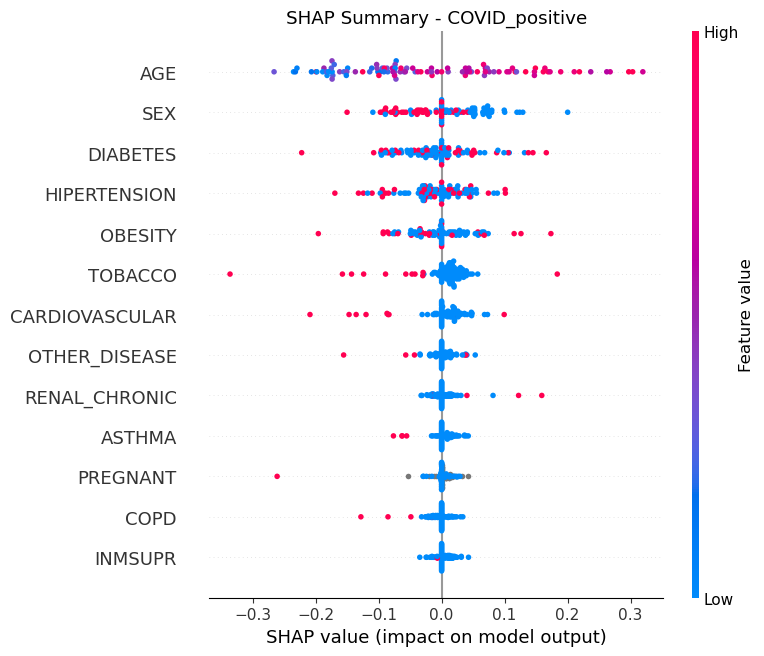

In [7]:
shap_POS = run_shap(result_POS, save_suffix="POS", n_background=50, n_eval=100, nsamples=100)


## 6.a) TRAINING COVID-NEGATIVE

In [8]:
result_NEG = train_and_evaluate("COVID_negative", DATA_NEG)



>>> Training: COVID_negative
------------------------------------------------------------
Feature matrix : (118035, 13)
Class distribution (0=survived, 1=deceased): {0: 108863, 1: 9172}

Best K (n_neighbors) : 7

--- Test-Set Metrics (CV-Mean +/- Std from the 3 inner folds) ---
Accuracy  : 0.8696   (CV: 0.8571 +/- 0.0012)
Recall    : 0.0747   (CV: 0.1029 +/- 0.0105)
Precision : 0.0902   (CV: 0.0983 +/- 0.0076)
F1-Score  : 0.0817   (CV: 0.1005 +/- 0.0090)
ROC-AUC   : 0.5825   (CV: 0.5900 +/- 0.0077)

Confusion Matrix:
              pred=0   pred=1
  true=0      20391     1382
  true=1       1697      137

Classification Report:
              precision    recall  f1-score   support

survived (0)       0.92      0.94      0.93     21773
deceased (1)       0.09      0.07      0.08      1834

    accuracy                           0.87     23607
   macro avg       0.51      0.51      0.51     23607
weighted avg       0.86      0.87      0.86     23607



## 6.b) SHAP ANALYSIS COVID-NEGATIVE


>>> SHAP Analysis for COVID_negative
(background=50, evaluation=100, nsamples=100)


100%|██████████| 100/100 [06:10<00:00,  3.70s/it]


  -> saved: kNN_plots\kNN_shap_summary_NEG.png


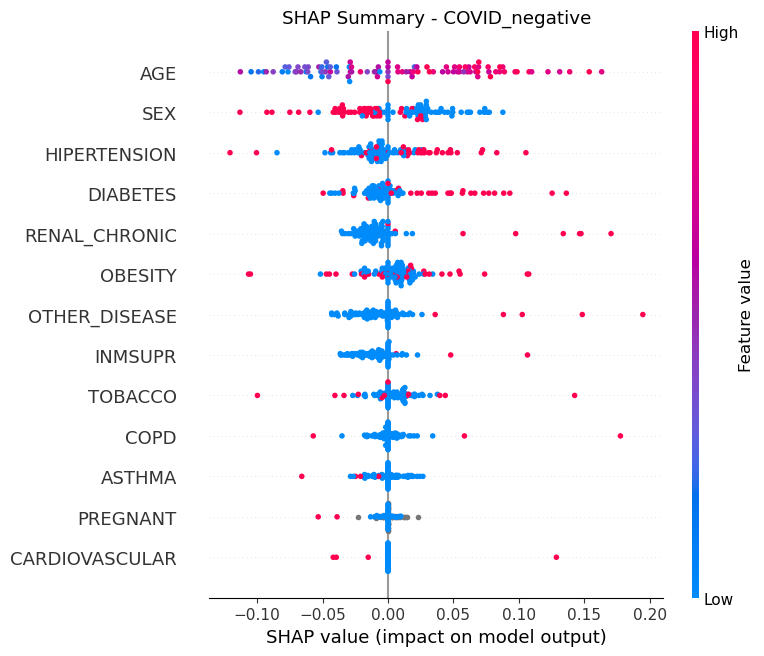

In [9]:
shap_NEG = run_shap(result_NEG, save_suffix="NEG", n_background=50, n_eval=100, nsamples=100)


## 7. COMPARISON

In [10]:
summary = pd.DataFrame([
    {"dataset": result_POS["name"], **result_POS["metrics"]},
    {"dataset": result_NEG["name"], **result_NEG["metrics"]},
])
print("=" * 70)
print("  COMPARISON OF BOTH RUNS")
print("=" * 70)
print(summary.round(4).to_string(index=False))


  COMPARISON OF BOTH RUNS
       dataset  best_k  accuracy  recall  precision     f1  roc_auc                                                                                                                                                                                                                                                                                                                                                      cv_stats
COVID_positive       3    0.7129  0.2494     0.3059 0.2748   0.5943   {'accuracy': {'mean': 0.7076121638340821, 'std': 0.0019420994905962998}, 'recall': {'mean': 0.26199003190967596, 'std': 0.017196917622470127}, 'precision': {'mean': 0.3027165856605544, 'std': 0.006968040770063211}, 'f1': {'mean': 0.2807405110756476, 'std': 0.0125827041965518}, 'roc_auc': {'mean': 0.5892144525112092, 'std': 0.006345296846521044}}
COVID_negative       7    0.8696  0.0747     0.0902 0.0817   0.5825 {'accuracy': {'mean': 0.8570657008514423, 'std': 0.0011545615004792012

## 8. CONFUSION MATRIX

  -> saved: kNN_plots\kNN_confusion_matrix_POS.png


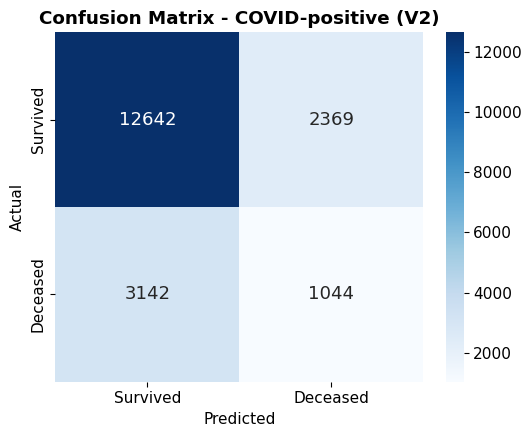

In [11]:
# Confusion Matrix - COVID-positive
cm = confusion_matrix(result_POS["y_test"], result_POS["y_pred"])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Survived", "Deceased"],
            yticklabels=["Survived", "Deceased"],
            annot_kws={"size": 13})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - COVID-positive (V2)", fontweight="bold")
plt.tight_layout()
save_plot("kNN_confusion_matrix_POS.png")
plt.show()


  -> saved: kNN_plots\kNN_confusion_matrix_NEG.png


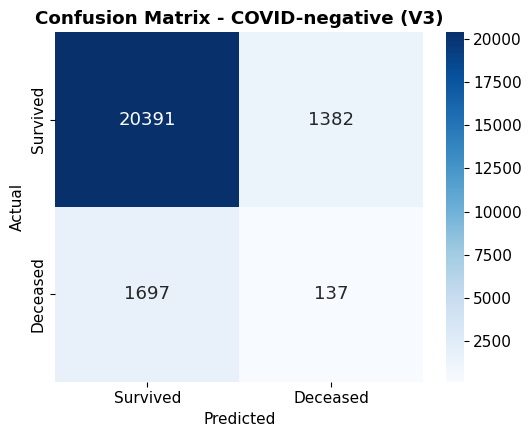

In [12]:
# Confusion Matrix - COVID-negative
cm = confusion_matrix(result_NEG["y_test"], result_NEG["y_pred"])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Survived", "Deceased"],
            yticklabels=["Survived", "Deceased"],
            annot_kws={"size": 13})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - COVID-negative (V3)", fontweight="bold")
plt.tight_layout()
save_plot("kNN_confusion_matrix_NEG.png")
plt.show()


## 9. CORRELATION MATRIX

  -> saved: kNN_plots\kNN_correlation_matrix_POS.png


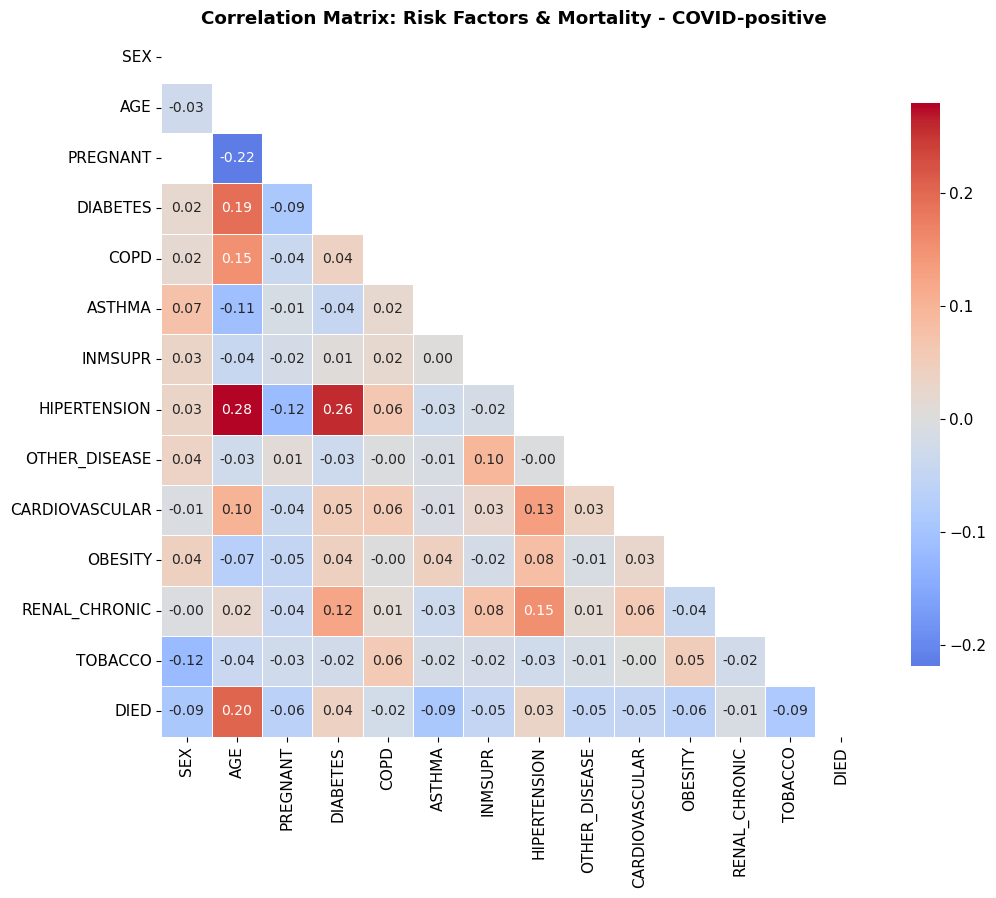

In [13]:
# Correlation Matrix - COVID-positive (lower triangular matrix)
corr_df = pd.concat([result_POS["X"], result_POS["y"].rename("DIED")], axis=1)
corr    = corr_df.corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))   # hide upper half

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})
plt.title("Correlation Matrix: Risk Factors & Mortality - COVID-positive",
          fontweight="bold")
plt.tight_layout()
save_plot("kNN_correlation_matrix_POS.png")
plt.show()


  -> saved: kNN_plots\kNN_correlation_matrix_NEG.png


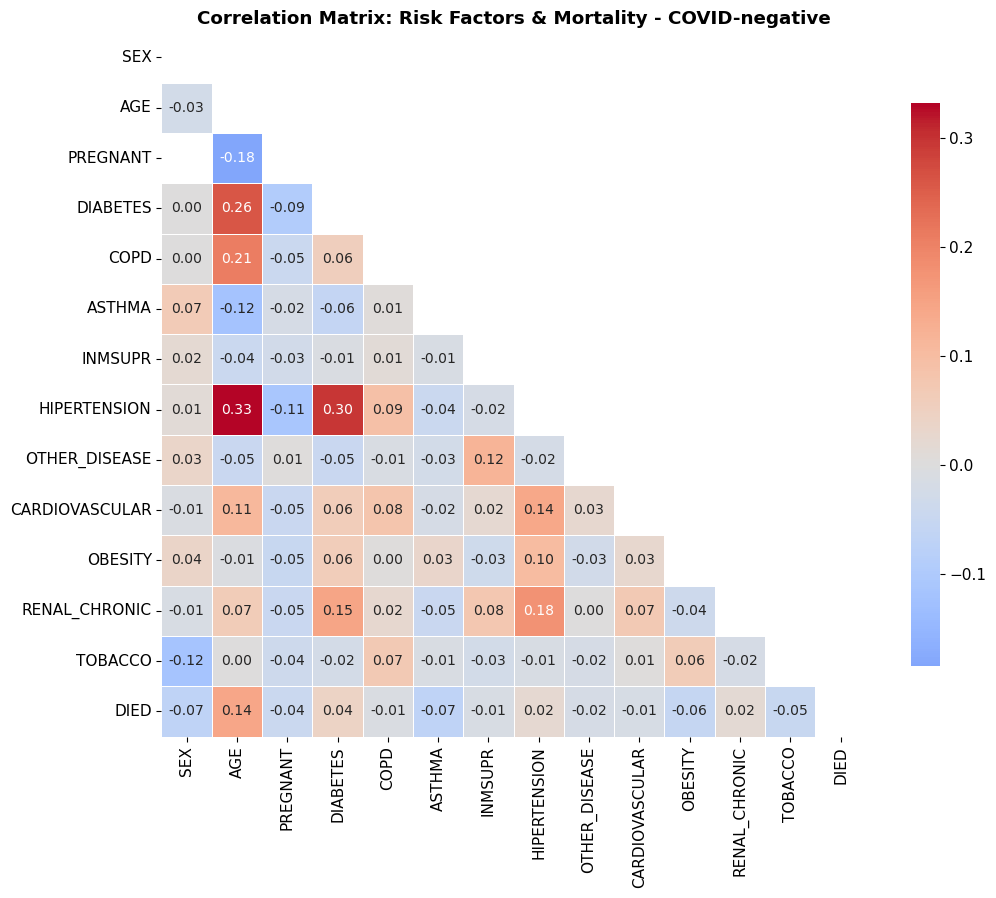

In [14]:
# Correlation Matrix - COVID-negative (lower triangular matrix)
corr_df = pd.concat([result_NEG["X"], result_NEG["y"].rename("DIED")], axis=1)
corr    = corr_df.corr()
mask    = np.triu(np.ones_like(corr, dtype=bool))   # hide upper half

plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})
plt.title("Correlation Matrix: Risk Factors & Mortality - COVID-negative",
          fontweight="bold")
plt.tight_layout()
save_plot("kNN_correlation_matrix_NEG.png")
plt.show()


## 10. ROC CURVE (Comparison of both models)

  -> saved: kNN_plots\kNN_roc_curve_comparison.png


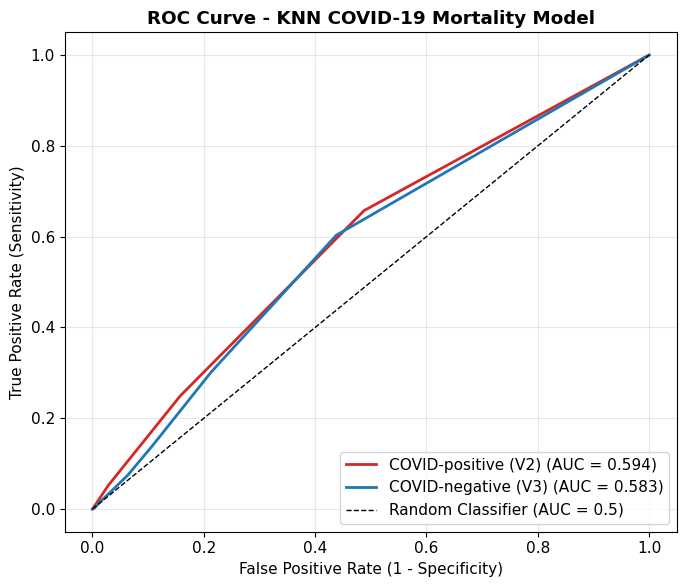

In [15]:
# ROC Curve - both models together
fpr_p, tpr_p, _ = roc_curve(result_POS["y_test"], result_POS["y_proba"])
fpr_n, tpr_n, _ = roc_curve(result_NEG["y_test"], result_NEG["y_proba"])
auc_p = result_POS["metrics"]["roc_auc"]
auc_n = result_NEG["metrics"]["roc_auc"]

plt.figure(figsize=(7, 6))
plt.plot(fpr_p, tpr_p, color="#d62728", linewidth=2,
         label=f"COVID-positive (V2) (AUC = {auc_p:.3f})")
plt.plot(fpr_n, tpr_n, color="#1f77b4", linewidth=2,
         label=f"COVID-negative (V3) (AUC = {auc_n:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1,
         label="Random Classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve - KNN COVID-19 Mortality Model", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot("kNN_roc_curve_comparison.png")
plt.show()


## 11. PRECISION-RECALL CURVE (Comparison of both models)

  -> saved: kNN_plots\kNN_precision_recall_curve_comparison.png


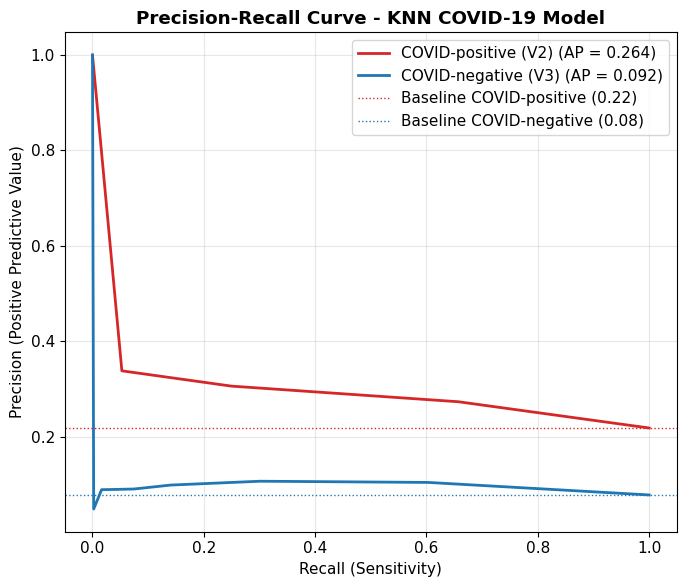

In [16]:
# Precision-Recall Curve - both models together
prec_p, rec_p, _ = precision_recall_curve(result_POS["y_test"], result_POS["y_proba"])
prec_n, rec_n, _ = precision_recall_curve(result_NEG["y_test"], result_NEG["y_proba"])
ap_p = average_precision_score(result_POS["y_test"], result_POS["y_proba"])
ap_n = average_precision_score(result_NEG["y_test"], result_NEG["y_proba"])

# Baselines = proportion of positive class in the test set
base_p = result_POS["y_test"].mean()
base_n = result_NEG["y_test"].mean()

plt.figure(figsize=(7, 6))
plt.plot(rec_p, prec_p, color="#d62728", linewidth=2,
         label=f"COVID-positive (V2) (AP = {ap_p:.3f})")
plt.plot(rec_n, prec_n, color="#1f77b4", linewidth=2,
         label=f"COVID-negative (V3) (AP = {ap_n:.3f})")
plt.axhline(base_p, color="#d62728", linestyle=":", linewidth=1,
            label=f"Baseline COVID-positive ({base_p:.2f})")
plt.axhline(base_n, color="#1f77b4", linestyle=":", linewidth=1,
            label=f"Baseline COVID-negative ({base_n:.2f})")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.title("Precision-Recall Curve - KNN COVID-19 Model", fontweight="bold")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
save_plot("kNN_precision_recall_curve_comparison.png")
plt.show()


## 12. DEATH RATE PER RISK FACTOR

In [17]:
# Helper function: death rate per binary risk factor
def death_rate_per_factor(X, y):
    df_full = pd.concat([X, y.rename("DIED")], axis=1)
    rates = {}
    for col in df_full.columns:
        if col in {"AGE", "DIED"}:
            continue
        vals = set(df_full[col].dropna().unique())
        if vals.issubset({0, 1}):
            mask = df_full[col] == 1
            if mask.sum() > 0:
                rates[col] = df_full.loc[mask, "DIED"].mean()
    return pd.Series(rates).sort_values()


  -> saved: kNN_plots\kNN_death_rate_POS.png


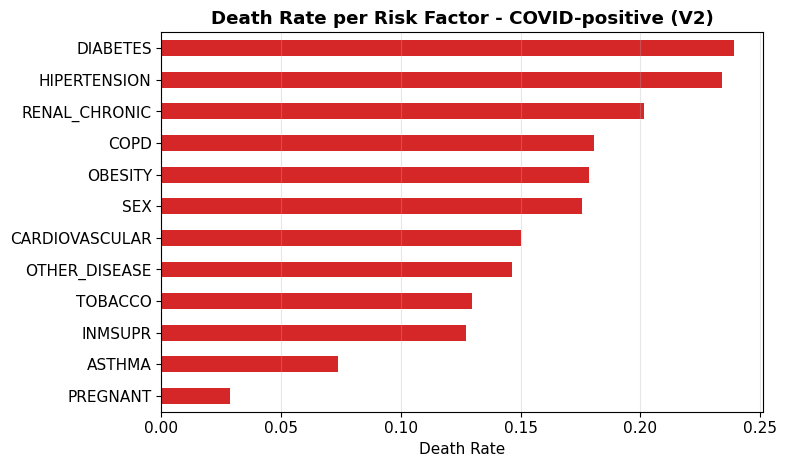

In [18]:
# Death Rate per Risk Factor - COVID-positive
rates_pos = death_rate_per_factor(result_POS["X"], result_POS["y"])

plt.figure(figsize=(8, max(4, 0.4 * len(rates_pos))))
rates_pos.plot(kind="barh", color="#d62728")
plt.xlabel("Death Rate")
plt.title("Death Rate per Risk Factor - COVID-positive (V2)", fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_plot("kNN_death_rate_POS.png")
plt.show()


  -> saved: kNN_plots\kNN_death_rate_NEG.png


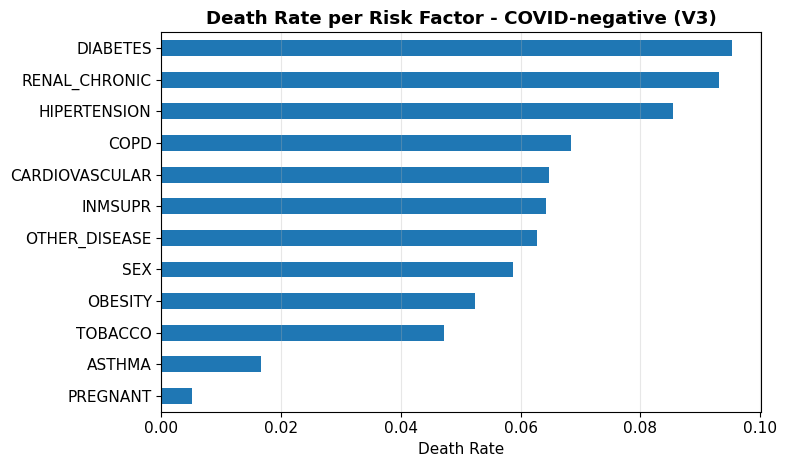

In [19]:
# Death Rate per Risk Factor - COVID-negative
rates_neg = death_rate_per_factor(result_NEG["X"], result_NEG["y"])

plt.figure(figsize=(8, max(4, 0.4 * len(rates_neg))))
rates_neg.plot(kind="barh", color="#1f77b4")
plt.xlabel("Death Rate")
plt.title("Death Rate per Risk Factor - COVID-negative (V3)", fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_plot("kNN_death_rate_NEG.png")
plt.show()
